In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

In [46]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

proc_lib='processing_utils'

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if proc_lib in sys.modules:
        print(f"Module {proc_lib} found in cache. Forcing reload...")
        importlib.reload(sys.modules['processing_utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    import processing_utils as proc
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your {proc_lib} file are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module processing_utils found in cache. Forcing reload...


# 0. Inputs

In [47]:
# Arguments. Test purpose only
input_dir = "/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52"
test_type = "default"
# loads_type = ["idle", "load-net", "load-usb", "load-net-usb"]
loads_type = ["idle", "load-net"]
channels = [0, 1]
nominal_period_us = 200000
duration_s = 10

# Create array of data to use in the loop
plots = []
for load_type in loads_type:
    for channel in channels:
        plots.append(proc.Plot_obj(input_dir, test_type, load_type, channel, nominal_period_us, duration_s))

Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'
Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'


# 1. Jitter plus

In [49]:
# Separate to idle and load
plots_idle = [obj for obj in plots if obj.load_type == "idle"]
phase_idle = proc.perform_phase_shift_analysis(plots_idle[0].result['edges_rise'], plots_idle[1].result['edges_rise'], nominal_period_us)

plots_load = [obj for obj in plots if obj.load_type == "load-net"]
phase_load = proc.perform_phase_shift_analysis(plots_load[0].result['edges_rise'], plots_load[1].result['edges_rise'], nominal_period_us)

In [50]:
print(vars(plots_idle[0]))

{'input_dir': '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52', 'csv_path': '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/idle/digital.csv', 'test_type': 'default', 'load_type': 'idle', 'channel': 0, 'duration_s': 10, 'nominal_period_us': 200000, 'jitter_title': 'Jitter Distribution (default under idle, Channel 0)', 'result': {'reference_time': Timestamp('2026-05-20 16:07:02.492933750'), 'time_jitter_rise': array([ 300060.,  500097.,  700134.,  900176., 1100239., 1300298.,
       1500356., 1700427., 1900488., 2100592., 2300659., 2500715.,
       2700780., 2900840., 3100920., 3300980., 3501035., 3701098.,
       3901171., 4101249., 4301313., 4501377., 4701436., 4901500.,
       5101577., 5301634., 5501691., 5701753., 5901816., 6101892.,
       6301948., 6502003., 6702064., 6902130., 7102210., 7302270.,
       7502329., 7702404., 7902496., 8102575., 8302636., 8502693.,
       8702748., 8902811., 91028

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_rise_0.png'


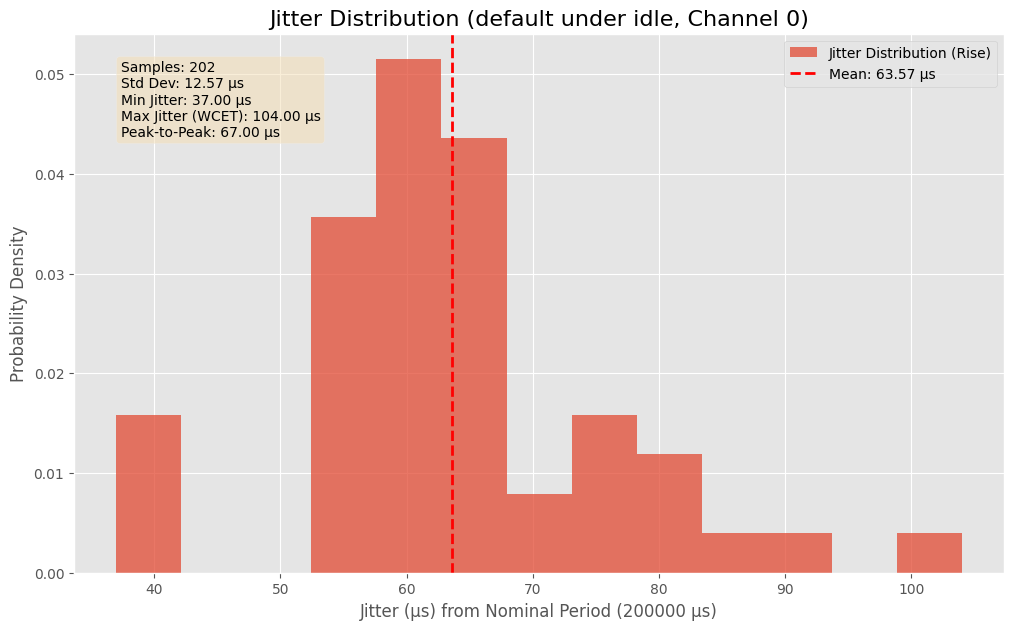

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_fall_0.png'


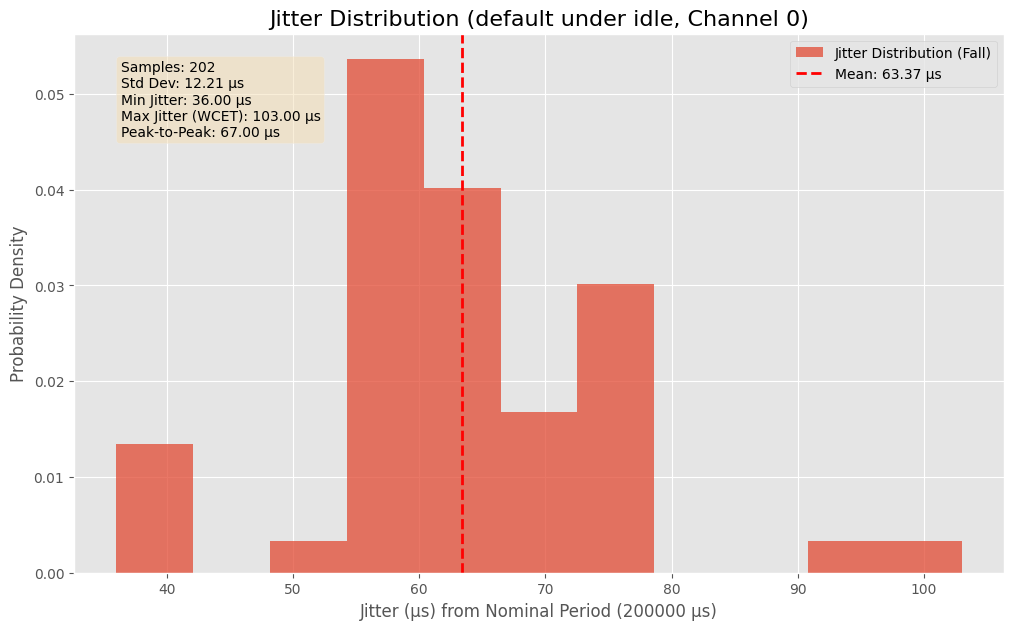

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_rise_fall_0.png'


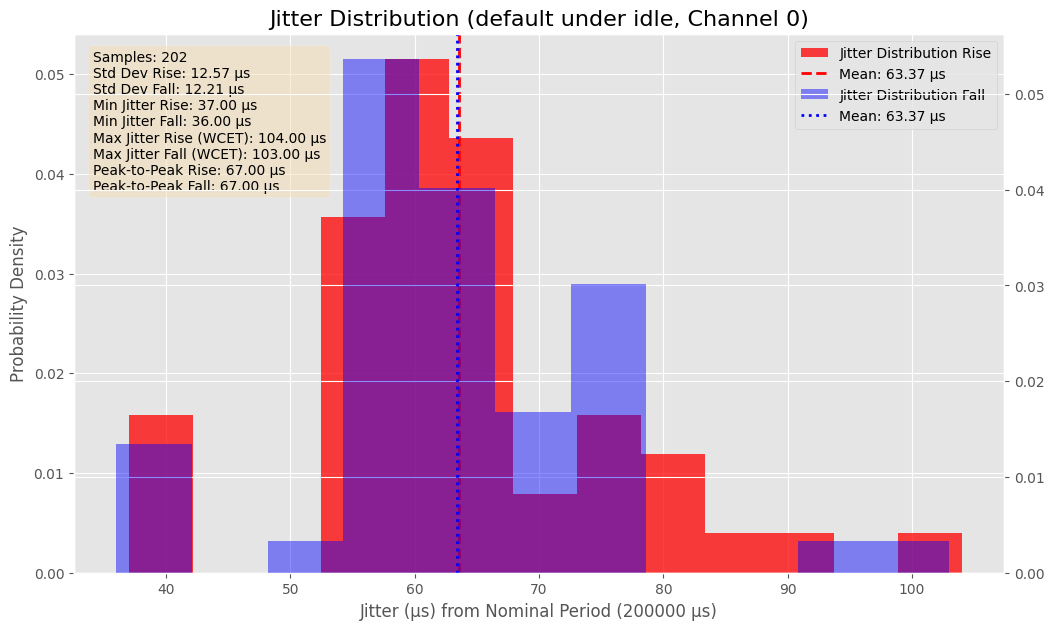

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_rise_1.png'


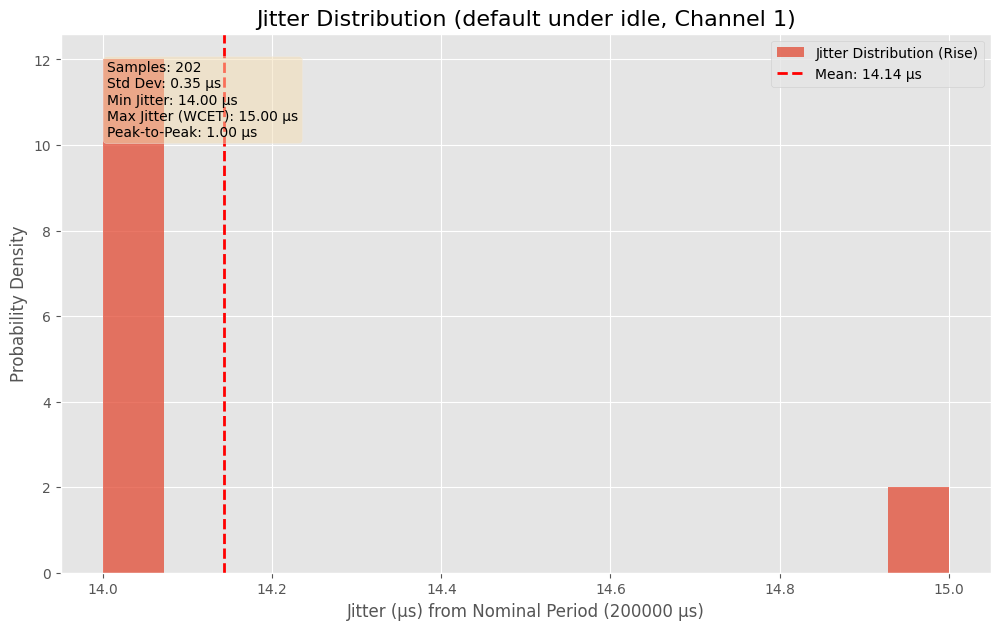

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_fall_1.png'


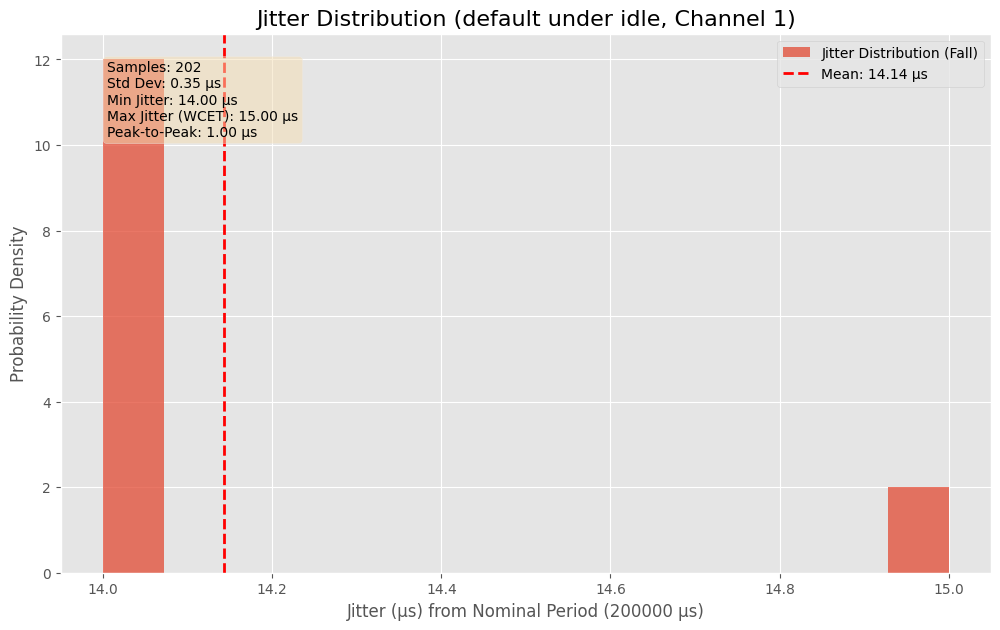

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_idle_rise_fall_1.png'


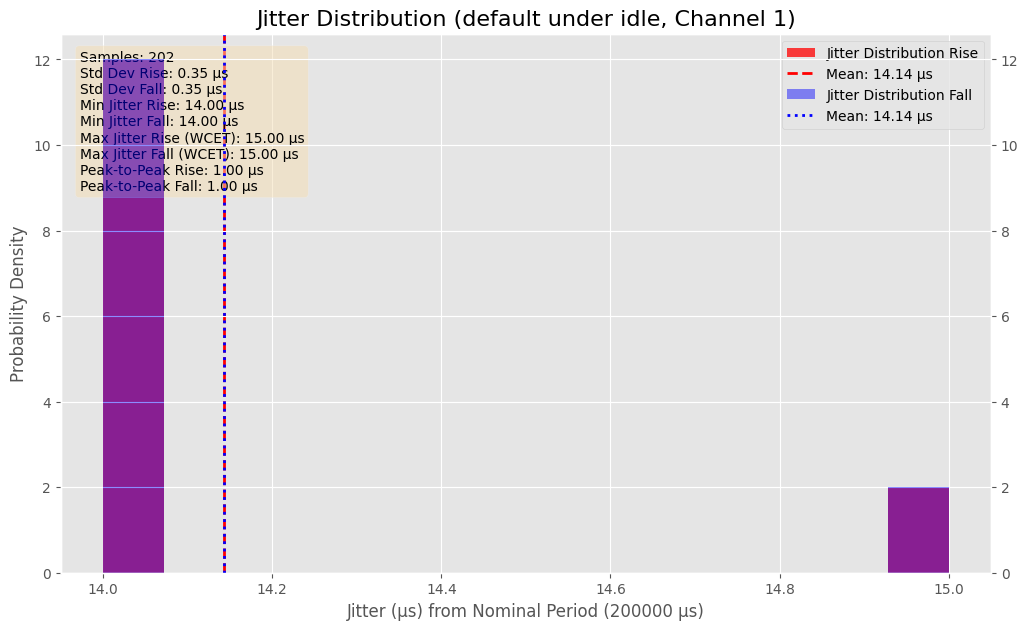

In [51]:
# Plot histogram idle
proc.plot_histograms(plots_idle, show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_rise_0.png'


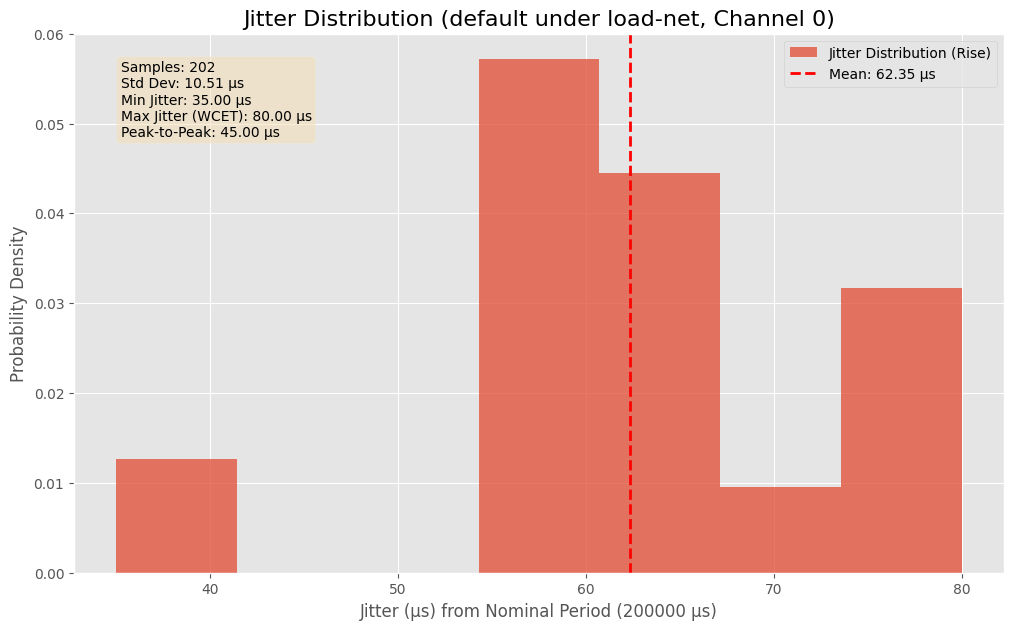

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_fall_0.png'


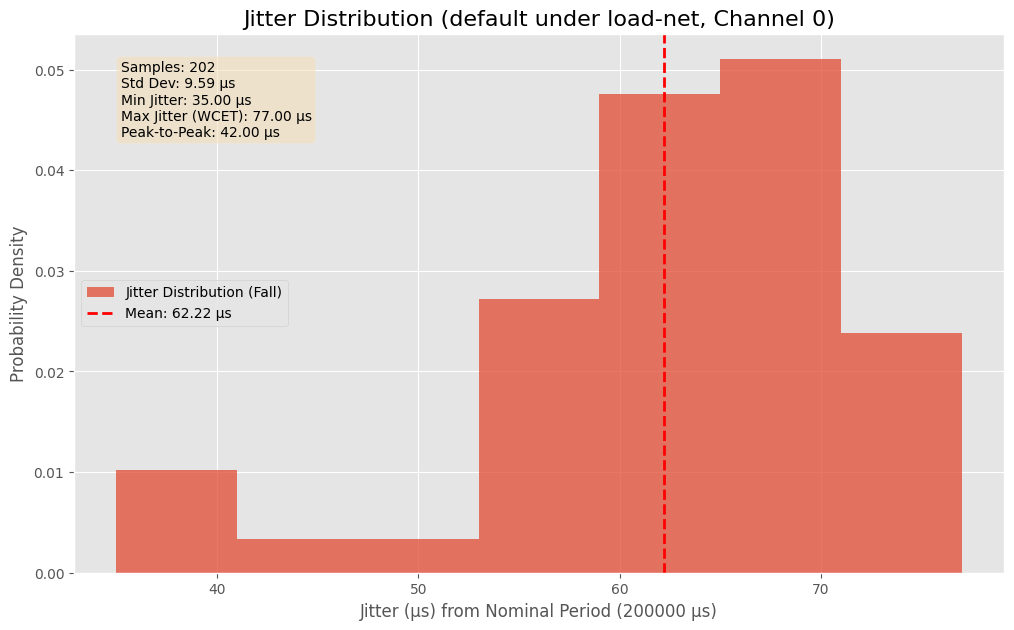

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_rise_fall_0.png'


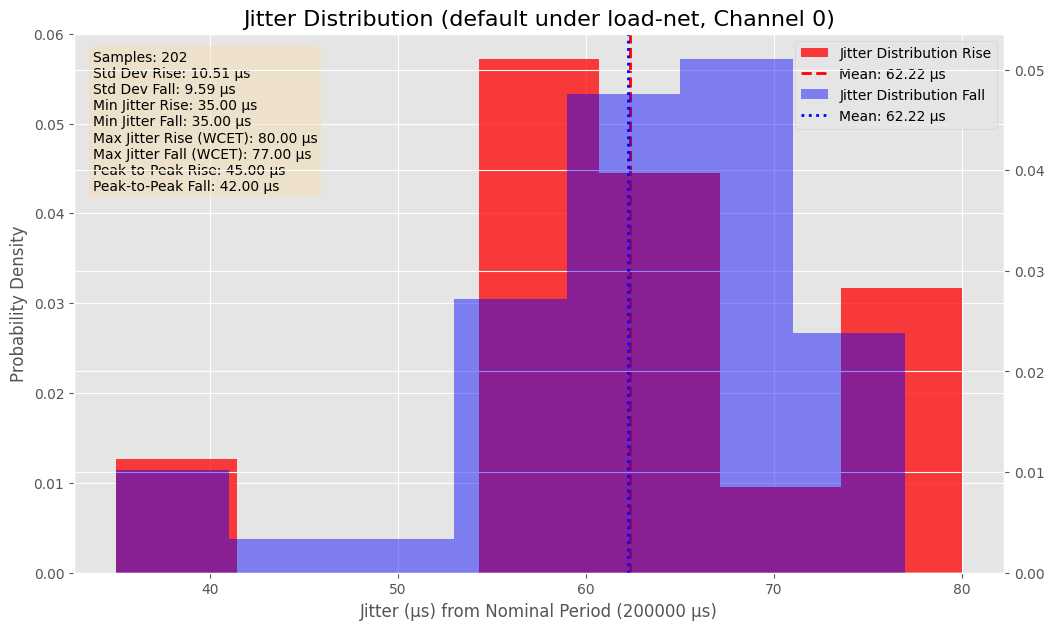

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_rise_1.png'


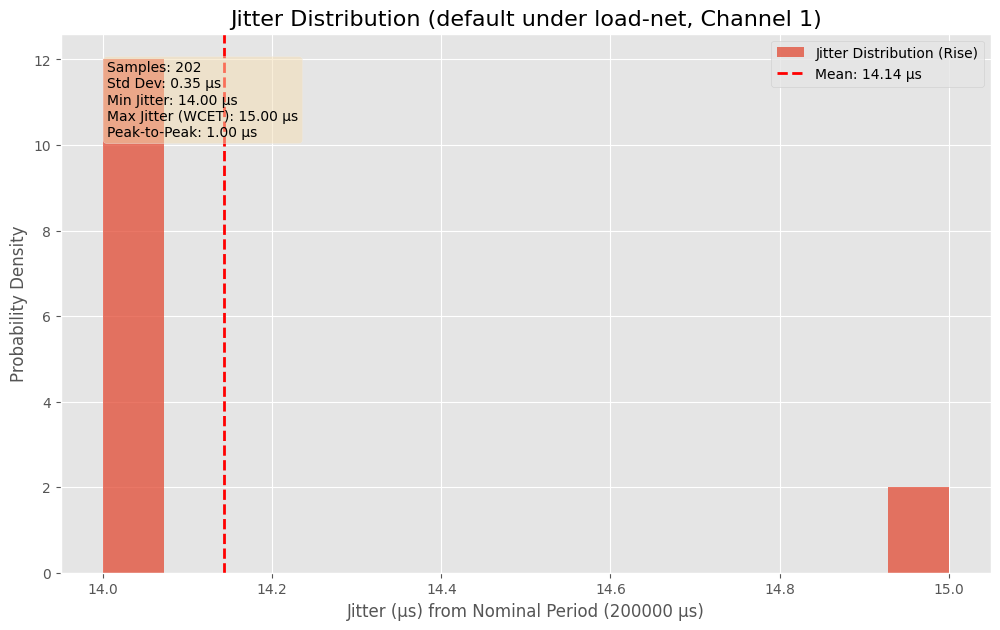

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_fall_1.png'


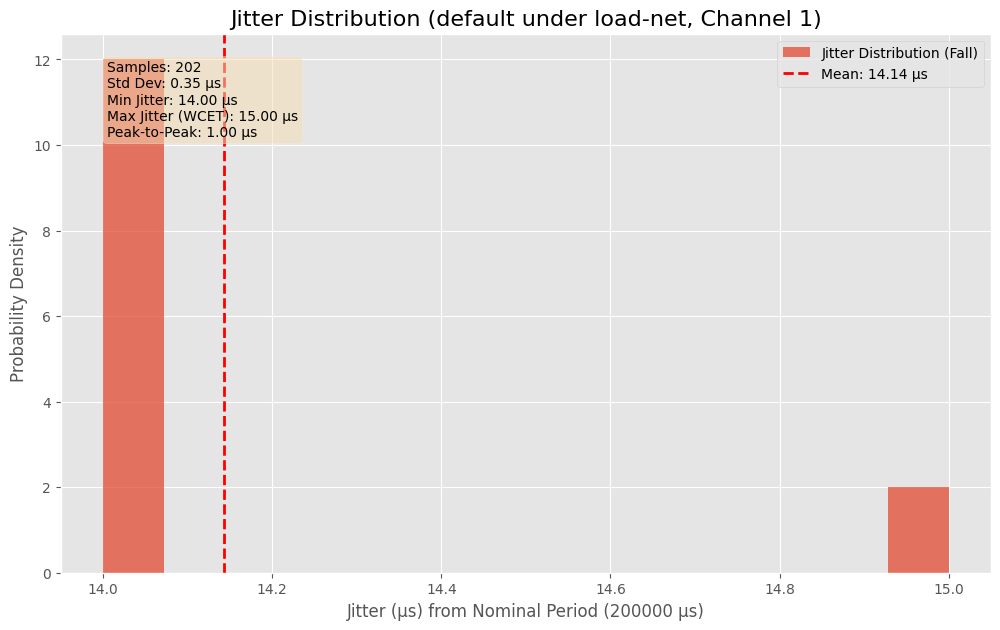

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_histogram_default_load-net_rise_fall_1.png'


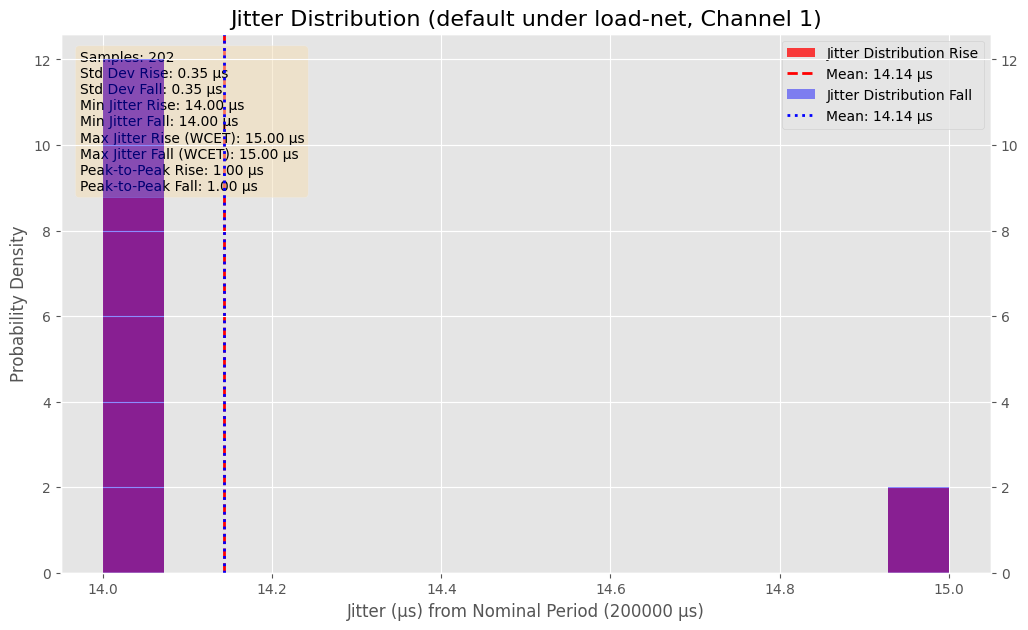

In [52]:
# Plot histogram load
proc.plot_histograms(plots_load, show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_phase_shift_default_idle.png'


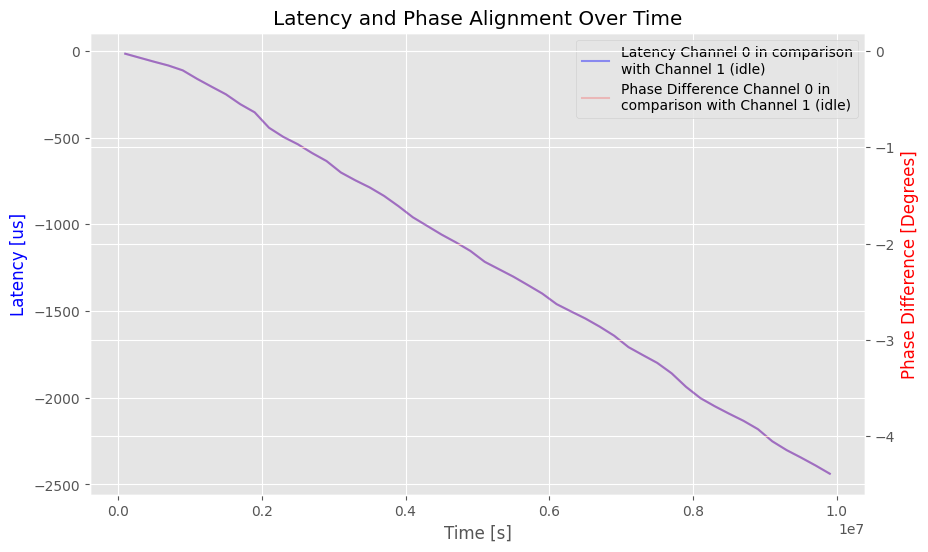

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_phase_shift_default_load-net.png'


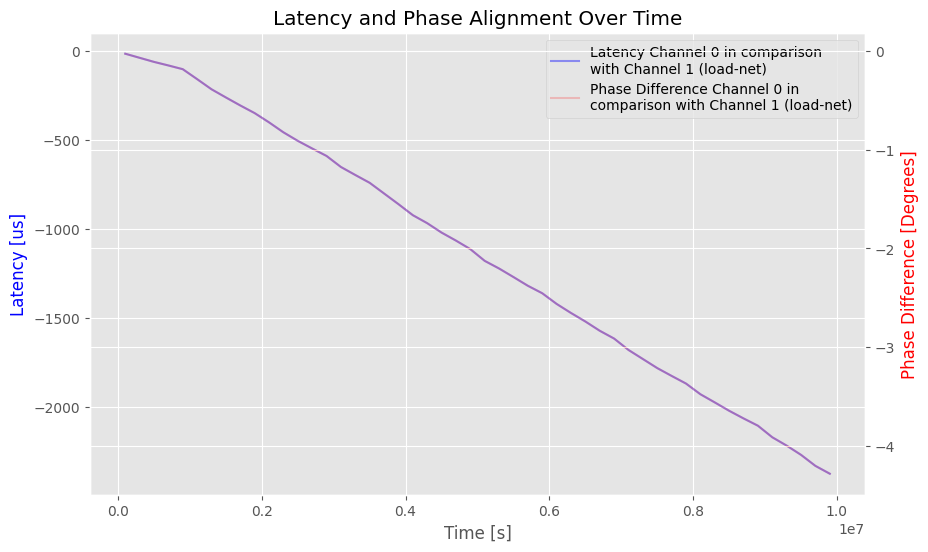

In [53]:
proc.plot_phase_shift_combined(phase_idle, plots_idle, show=True)
proc.plot_phase_shift_combined(phase_load, plots_load, show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_idle_rise_fall_0.png'


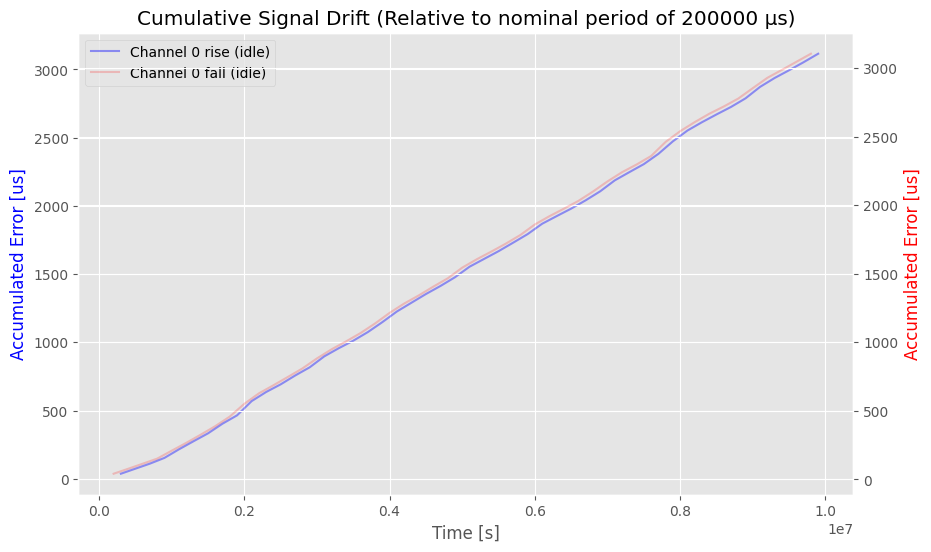

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_idle_rise_fall_1.png'


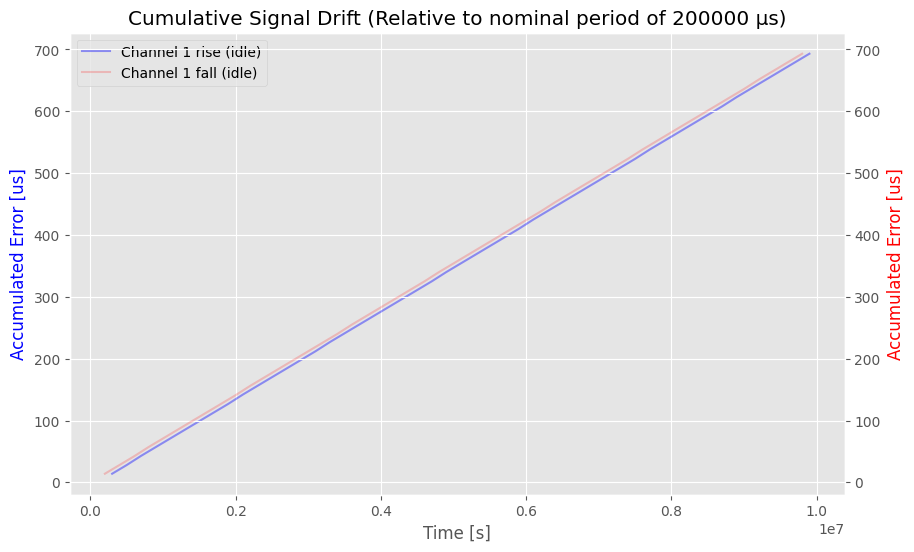

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_load-net_rise_fall_0.png'


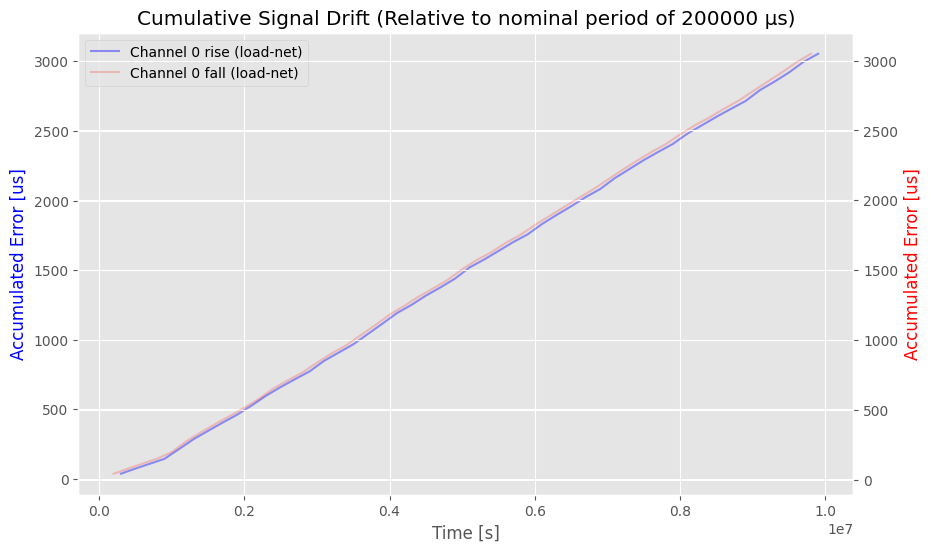

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_load-net_rise_fall_1.png'


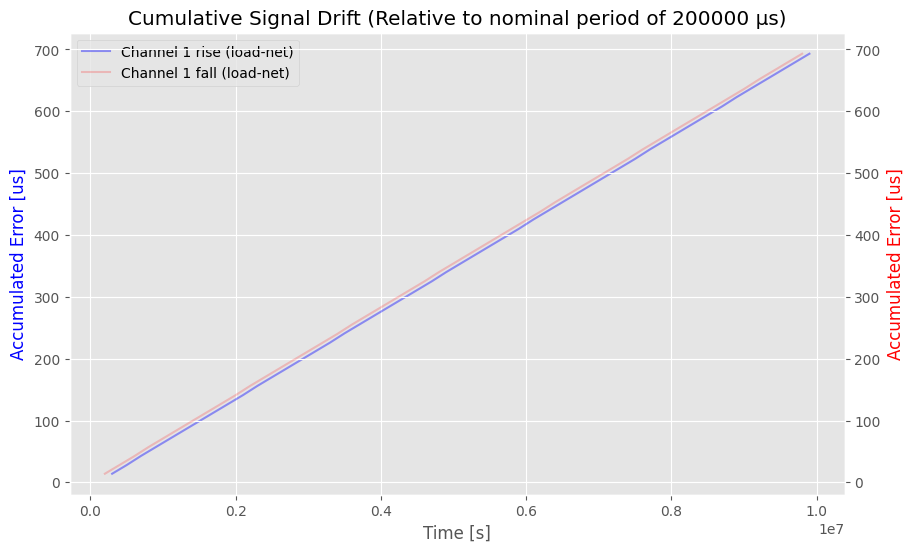

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_idle_0_1.png'


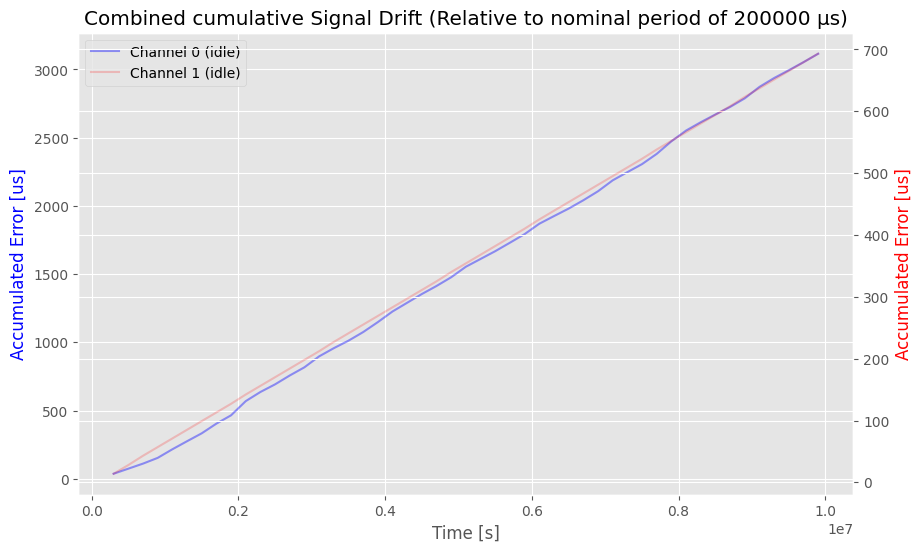

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_signal_drift_default_load-net_0_1.png'


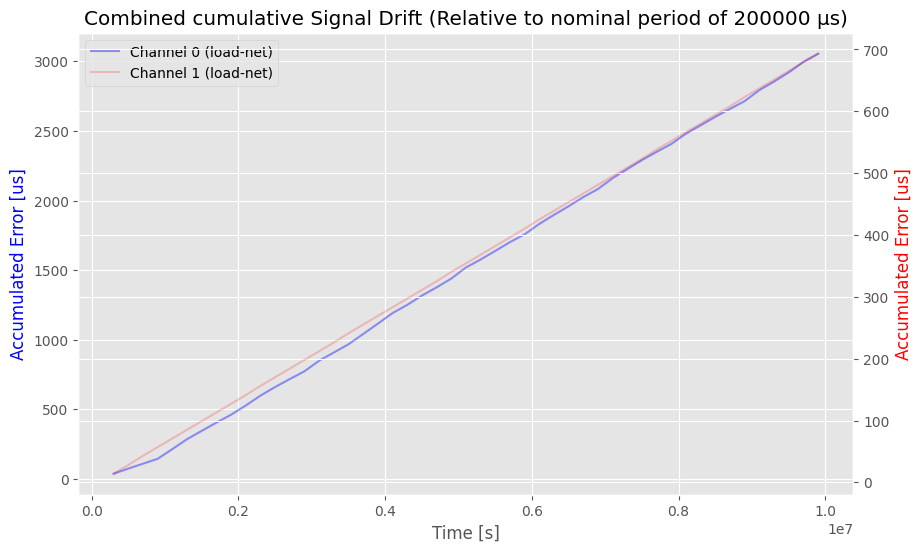

In [54]:
# Individual
proc.plot_signal_drift(plots_idle, show=True)
proc.plot_signal_drift(plots_load, show=True)

# Combined
proc.plot_signal_drift_combined(plots_idle[0], plots_idle[1], show=True)
proc.plot_signal_drift_combined(plots_load[0], plots_load[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_duty_cycle_default_idle.png'


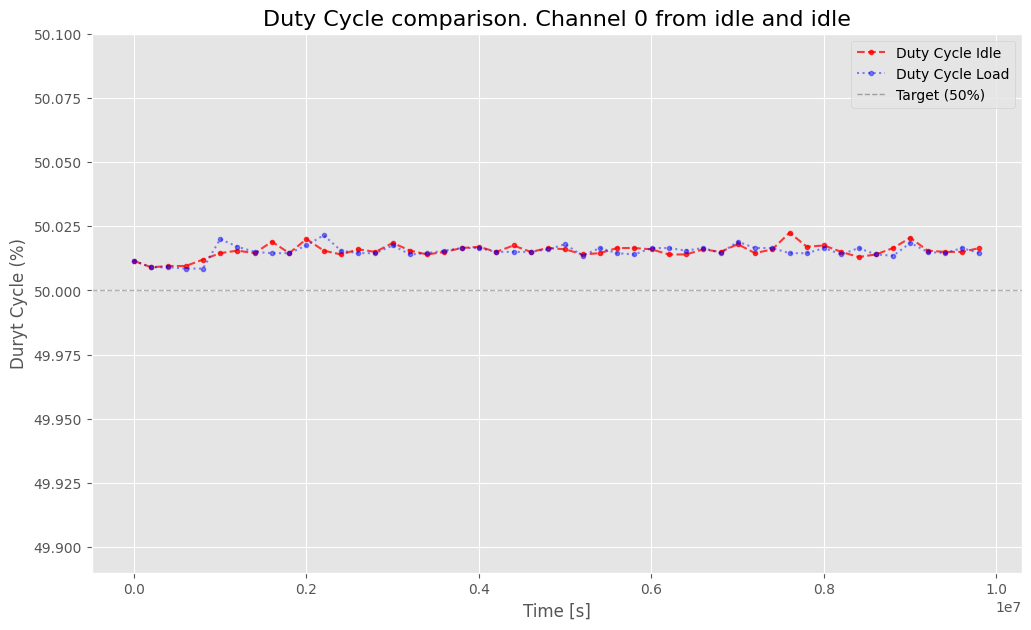

In [55]:
pli = plots_idle[0]
pll = plots_load[0]
plp = plots_idle[0]
title = f"Duty Cycle comparison. Channel {pli.channel} from {pli.load_type} and {pli.load_type}"
proc.plot_duty_cycle_combined(pli.result, pll.result, title, proc.plot_path(plp, "duty_cycle", "",combined=True), show=True, y_lim=(49.89, 50.1))

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-20-19-06-52/jitter_duty_cycle_default_load-net.png'


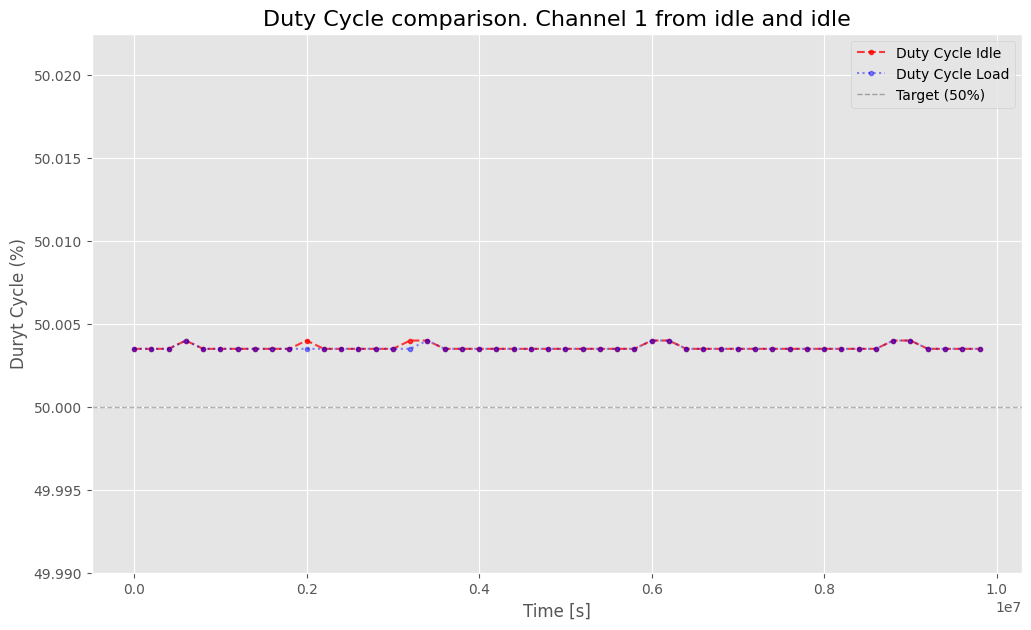

In [56]:
pli = plots_idle[1]
pll = plots_load[1]
plp = plots_load[0]
title = f"Duty Cycle comparison. Channel {pli.channel} from {pli.load_type} and {pli.load_type}"
proc.plot_duty_cycle_combined(pli.result, pll.result, title,
                              proc.plot_path(plp, "duty_cycle", "",combined=True),
                              show=True, y_lim=(49.99, 50.0225))